#  Predictive Modeling using Boosting Techniques
## Bank Marketing Dataset | XGBoost · LightGBM · CatBoost | RandomizedSearchCV
---

## Install Libraries

In [ ]:
!pip install xgboost lightgbm catboost ucimlrepo -q

##  Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

##  Load Dataset
We use the **Bank Marketing** dataset from the UCI Machine Learning Repository.
It contains information about direct marketing campaigns of a Portuguese bank.
The goal is to predict whether a client will subscribe to a term deposit (`yes` / `no`).

In [ ]:
# Fetch dataset from UCI
bank = fetch_ucirepo(id=222)

# Separate features and target
X_raw = bank.data.features.copy()
y_raw = bank.data.targets.copy().squeeze()

# Combine for EDA
df = X_raw.copy()
df['y'] = y_raw

print("Dataset loaded successfully!")
print(f"Total rows    : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")
print()
print("First 5 rows:")
df.head()

Dataset loaded successfully!
Total rows    : 45211
Total columns : 17

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


##  Exploratory Data Analysis (EDA)

###  Data Types and Missing Values

In [ ]:
print("Column Info:")
print("-" * 45)
for col in df.columns:
    missing = df[col].isnull().sum()
    print(f"  {col:<25} dtype: {str(df[col].dtype):<10}  missing: {missing}")

Column Info:
---------------------------------------------
  age                       dtype: int64       missing: 0
  job                       dtype: object      missing: 288
  marital                   dtype: object      missing: 0
  education                 dtype: object      missing: 1857
  default                   dtype: object      missing: 0
  balance                   dtype: int64       missing: 0
  housing                   dtype: object      missing: 0
  loan                      dtype: object      missing: 0
  contact                   dtype: object      missing: 13020
  day_of_week               dtype: int64       missing: 0
  month                     dtype: object      missing: 0
  duration                  dtype: int64       missing: 0
  campaign                  dtype: int64       missing: 0
  pdays                     dtype: int64       missing: 0
  previous                  dtype: int64       missing: 0
  poutcome                  dtype: object      missing: 36959


###  Basic Statistics

In [ ]:
df.describe().round(2)

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


###  Target Class Distribution

Class Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Imbalance ratio: 39922 : 5289


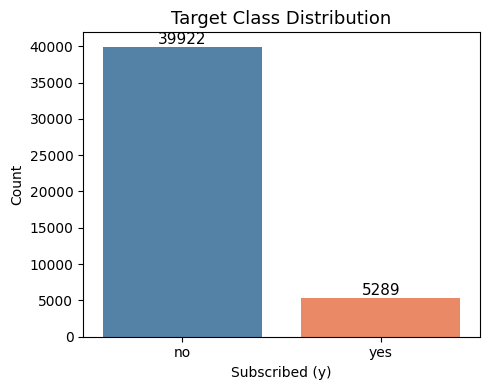

In [ ]:
target_counts = df['y'].value_counts()
print("Class Counts:")
print(target_counts)
print()
print(f"Imbalance ratio: {target_counts.max()} : {target_counts.min()}")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='y', palette=['steelblue', 'coral'])
plt.title("Target Class Distribution", fontsize=13)
plt.xlabel("Subscribed (y)")
plt.ylabel("Count")
for p in plt.gca().patches:
    plt.gca().annotate(str(int(p.get_height())),
                       (p.get_x() + p.get_width() / 2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### Age Distribution by Class

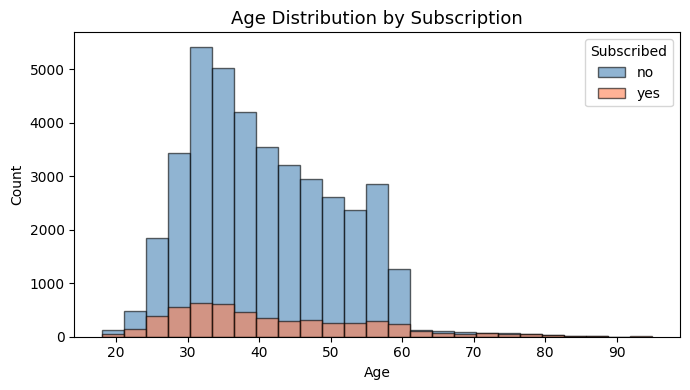

In [ ]:
plt.figure(figsize=(7, 4))
for cls, color in zip(['no', 'yes'], ['steelblue', 'coral']):
    subset = df[df['y'] == cls]['age']
    plt.hist(subset, bins=25, alpha=0.6, label=cls, color=color, edgecolor='black')
plt.title("Age Distribution by Subscription", fontsize=13)
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title="Subscribed")
plt.tight_layout()
plt.show()

###  Subscription Rate by Job

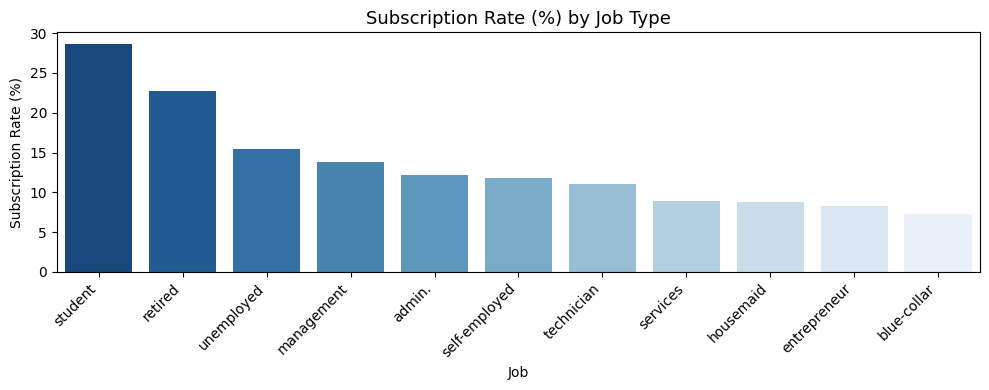

In [ ]:
job_rate = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=job_rate.index, y=job_rate.values, palette='Blues_r')
plt.title("Subscription Rate (%) by Job Type", fontsize=13)
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###  Correlation Heatmap (Numerical Features)

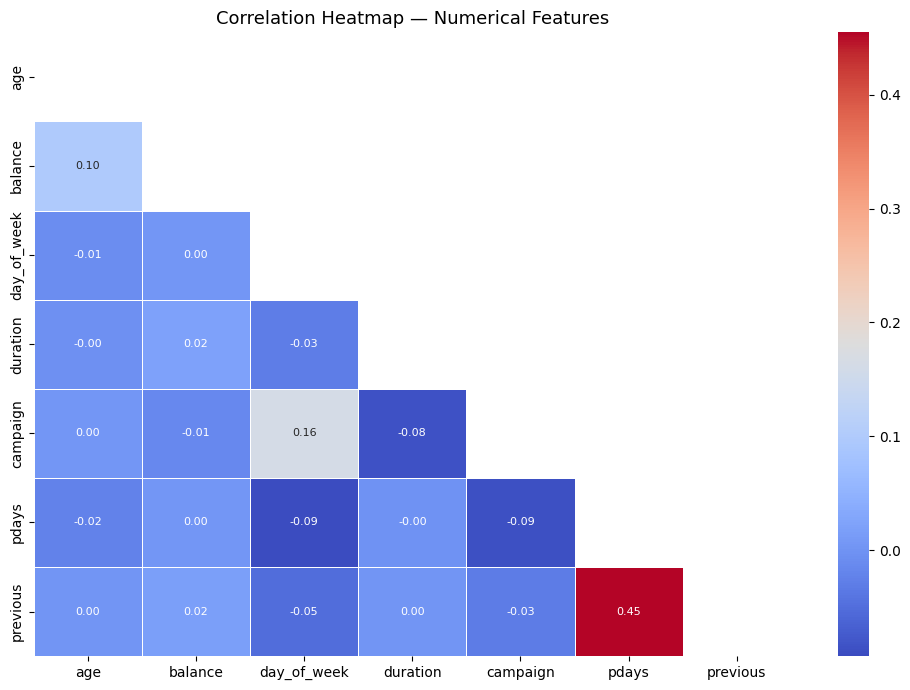

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title("Correlation Heatmap — Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

##  Feature Engineering

###  Encode Target Variable

In [ ]:
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw.astype(str))

print("Target encoding:")
for cls, code in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    print(f"  '{cls}' --> {code}")

Target encoding:
  'no' --> 0
  'yes' --> 1


### Encode Categorical Columns

In [ ]:
X = X_raw.copy()

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")
print()

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding done!")
print(X[cat_cols].head())

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Encoding done!
   job  marital  education  default  housing  loan  contact  month  poutcome
0    4        1          3        0        1     0        1      8         1
1   10        2          2        0        1     0        1      8         1
2    2        1          2        0        1     1        1      8         1
3    1        1          0        0        1     0        1      8         1
4    5        2          0        0        0     0        1      8         1


###  Scale Numerical Columns

In [ ]:
num_cols = X.select_dtypes(include='number').columns.tolist()
print(f"Numerical columns to scale: {num_cols}")

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print()
print("Scaling done! Sample values after scaling:")
X[num_cols].head()

Numerical columns to scale: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Scaling done! Sample values after scaling:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,1.606965,-0.190047,-0.275762,1.206484,-0.13549,0.256419,0.893915,-0.436803,0.957159,-1.298476,0.823773,0.011016,-0.569351,-0.411453,-0.25194,0.001622
1,0.288529,1.448230,1.368372,-0.077715,-0.13549,-0.437895,0.893915,-0.436803,0.957159,-1.298476,0.823773,-0.416127,-0.569351,-0.411453,-0.25194,0.001622
2,-0.747384,-0.736140,-0.275762,-0.077715,-0.13549,-0.446762,0.893915,2.289359,0.957159,-1.298476,0.823773,-0.707361,-0.569351,-0.411453,-0.25194,0.001622
3,0.571051,-1.009186,-0.275762,-2.646114,-0.13549,0.047205,0.893915,-0.436803,0.957159,-1.298476,0.823773,-0.645231,-0.569351,-0.411453,-0.25194,0.001622
4,-0.747384,0.082999,1.368372,-2.646114,-0.13549,-0.447091,-1.118674,-0.436803,0.957159,-1.298476,0.823773,-0.233620,-0.569351,-0.411453,-0.25194,0.001622


### Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 36168
Testing  samples : 9043
Features         : 16


##  Base Model Training (Default Parameters)

###  Function to Evaluate Any Model

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1-Score' : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
    }
    return results

### Train XGBoost (Base)

In [ ]:
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                               use_label_encoder=False, verbosity=0)
xgb_base_scores = evaluate_model(xgb_base, X_train, y_train, X_test, y_test)

print("XGBoost — Base Model Results:")
for metric, score in xgb_base_scores.items():
    print(f"  {metric:<12}: {score}")

XGBoost — Base Model Results:
  Accuracy    : 0.9045
  Precision   : 0.6222
  Recall      : 0.4669
  F1-Score    : 0.5335
  ROC-AUC     : 0.9279


### Train LightGBM (Base)

In [ ]:
lgb_base = lgb.LGBMClassifier(random_state=42, verbosity=-1)
lgb_base_scores = evaluate_model(lgb_base, X_train, y_train, X_test, y_test)

print("LightGBM — Base Model Results:")
for metric, score in lgb_base_scores.items():
    print(f"  {metric:<12}: {score}")

LightGBM — Base Model Results:
  Accuracy    : 0.9092
  Precision   : 0.6545
  Recall      : 0.4745
  F1-Score    : 0.5501
  ROC-AUC     : 0.9339


### Train CatBoost (Base)

In [ ]:
cat_base = cb.CatBoostClassifier(random_state=42, verbose=0)
cat_base_scores = evaluate_model(cat_base, X_train, y_train, X_test, y_test)

print("CatBoost — Base Model Results:")
for metric, score in cat_base_scores.items():
    print(f"  {metric:<12}: {score}")

CatBoost — Base Model Results:
  Accuracy    : 0.9092
  Precision   : 0.6537
  Recall      : 0.4764
  F1-Score    : 0.5511
  ROC-AUC     : 0.9341


### Base Models Comparison Table

In [ ]:
base_df = pd.DataFrame({
    'XGBoost' : xgb_base_scores,
    'LightGBM': lgb_base_scores,
    'CatBoost': cat_base_scores
}).T

print("Base Model Comparison:")
base_df

Base Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.9045,0.6222,0.4669,0.5335,0.9279
LightGBM,0.9092,0.6545,0.4745,0.5501,0.9339
CatBoost,0.9092,0.6537,0.4764,0.5511,0.9341


##  Hyperparameter Tuning with RandomizedSearchCV

###  Setup Cross-Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("5-Fold Stratified Cross-Validation ready.")

5-Fold Stratified Cross-Validation ready.


### Tune XGBoost

In [ ]:
xgb_params = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.5],
    'reg_alpha'       : [0, 0.01, 0.1, 1],
    'reg_lambda'      : [1, 1.5, 2, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                                 use_label_encoder=False, verbosity=0),
    param_distributions=xgb_params,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print()
print("Best XGBoost Parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1-Score: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost Parameters:
  subsample: 0.8
  reg_lambda: 1.5
  reg_alpha: 0
  n_estimators: 200
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.1
  gamma: 0.5
  colsample_bytree: 0.8
Best CV F1-Score: 0.5484


###  Tune LightGBM

In [ ]:
lgb_params = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [-1, 5, 7, 10, 15],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'       : [20, 31, 50, 70, 100],
    'min_child_samples': [10, 20, 30, 50],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.8, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 1],
    'reg_lambda'       : [0, 0.01, 0.1, 1],
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbosity=-1),
    param_distributions=lgb_params,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgb_search.fit(X_train, y_train)

print()
print("Best LightGBM Parameters:")
for k, v in lgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1-Score: {lgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best LightGBM Parameters:
  subsample: 0.7
  reg_lambda: 0.1
  reg_alpha: 1
  num_leaves: 20
  n_estimators: 200
  min_child_samples: 30
  max_depth: 10
  learning_rate: 0.2
  colsample_bytree: 0.8
Best CV F1-Score: 0.5546


###  Tune CatBoost

In [ ]:
cat_params = {
    'iterations'        : [100, 200, 300, 500],
    'depth'             : [4, 5, 6, 7, 8],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg'       : [1, 3, 5, 7, 10],
    'bagging_temperature': [0, 0.5, 1.0, 2.0],
    'border_count'      : [32, 64, 128, 254],
    'random_strength'   : [0, 0.5, 1.0, 2.0],
}

cat_search = RandomizedSearchCV(
    estimator=cb.CatBoostClassifier(random_state=42, verbose=0),
    param_distributions=cat_params,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cat_search.fit(X_train, y_train)

print()
print("Best CatBoost Parameters:")
for k, v in cat_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1-Score: {cat_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CatBoost Parameters:
  random_strength: 1.0
  learning_rate: 0.1
  l2_leaf_reg: 3
  iterations: 500
  depth: 7
  border_count: 128
  bagging_temperature: 0
Best CV F1-Score: 0.5514


## 📈  Evaluate Tuned Models

###  Score All Tuned Models

In [ ]:
xgb_tuned_scores = evaluate_model(xgb_search.best_estimator_, X_train, y_train, X_test, y_test)
lgb_tuned_scores = evaluate_model(lgb_search.best_estimator_, X_train, y_train, X_test, y_test)
cat_tuned_scores = evaluate_model(cat_search.best_estimator_, X_train, y_train, X_test, y_test)

print("XGBoost Tuned :", xgb_tuned_scores)
print("LightGBM Tuned:", lgb_tuned_scores)
print("CatBoost Tuned:", cat_tuned_scores)

XGBoost Tuned : {'Accuracy': 0.9081, 'Precision': 0.6421, 'Recall': 0.4849, 'F1-Score': 0.5525, 'ROC-AUC': np.float64(0.9305)}
LightGBM Tuned: {'Accuracy': 0.9081, 'Precision': 0.6382, 'Recall': 0.4953, 'F1-Score': 0.5577, 'ROC-AUC': np.float64(0.9315)}
CatBoost Tuned: {'Accuracy': 0.9093, 'Precision': 0.6503, 'Recall': 0.4868, 'F1-Score': 0.5568, 'ROC-AUC': np.float64(0.9324)}


###  Full Comparison Table (Base vs Tuned)

In [ ]:
comparison = pd.DataFrame({
    'XGBoost  Base' : xgb_base_scores,
    'XGBoost  Tuned': xgb_tuned_scores,
    'LightGBM Base' : lgb_base_scores,
    'LightGBM Tuned': lgb_tuned_scores,
    'CatBoost Base' : cat_base_scores,
    'CatBoost Tuned': cat_tuned_scores,
}).T

print("Full Comparison Table:")
comparison

Full Comparison Table:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost Base,0.9045,0.6222,0.4669,0.5335,0.9279
XGBoost Tuned,0.9081,0.6421,0.4849,0.5525,0.9305
LightGBM Base,0.9092,0.6545,0.4745,0.5501,0.9339
LightGBM Tuned,0.9081,0.6382,0.4953,0.5577,0.9315
CatBoost Base,0.9092,0.6537,0.4764,0.5511,0.9341
CatBoost Tuned,0.9093,0.6503,0.4868,0.5568,0.9324


###  Comparision of Improvement After Tuning

In [ ]:
print("Improvement After Hyperparameter Tuning:")
print("-" * 45)

models = ['XGBoost', 'LightGBM', 'CatBoost']
base_list  = [xgb_base_scores,  lgb_base_scores,  cat_base_scores]
tuned_list = [xgb_tuned_scores, lgb_tuned_scores, cat_tuned_scores]

for name, base, tuned in zip(models, base_list, tuned_list):
    delta_f1  = tuned['F1-Score'] - base['F1-Score']
    delta_auc = tuned['ROC-AUC']  - base['ROC-AUC']
    print(f"{name:<12}  F1 change: {delta_f1:+.4f}   AUC change: {delta_auc:+.4f}")

Improvement After Hyperparameter Tuning:
---------------------------------------------
XGBoost       F1 change: +0.0190   AUC change: +0.0026
LightGBM      F1 change: +0.0076   AUC change: -0.0024
CatBoost      F1 change: +0.0057   AUC change: -0.0017


## AI Generated Code Visualisations

###  Base vs Tuned F1-Score Comparison

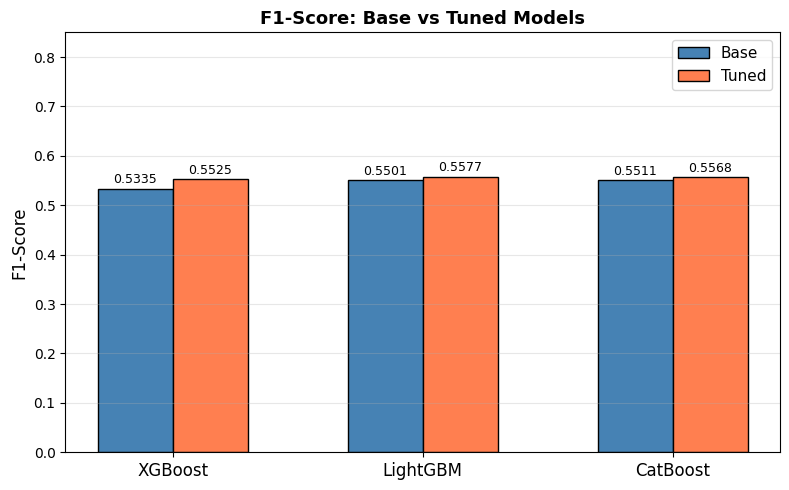

In [ ]:
models   = ['XGBoost', 'LightGBM', 'CatBoost']
base_f1  = [xgb_base_scores['F1-Score'],  lgb_base_scores['F1-Score'],  cat_base_scores['F1-Score']]
tuned_f1 = [xgb_tuned_scores['F1-Score'], lgb_tuned_scores['F1-Score'], cat_tuned_scores['F1-Score']]

x = np.arange(len(models))
width = 0.30

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, base_f1,  width, label='Base',  color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, tuned_f1, width, label='Tuned', color='coral',     edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_title("F1-Score: Base vs Tuned Models", fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### All Metrics Comparison (Tuned Models)

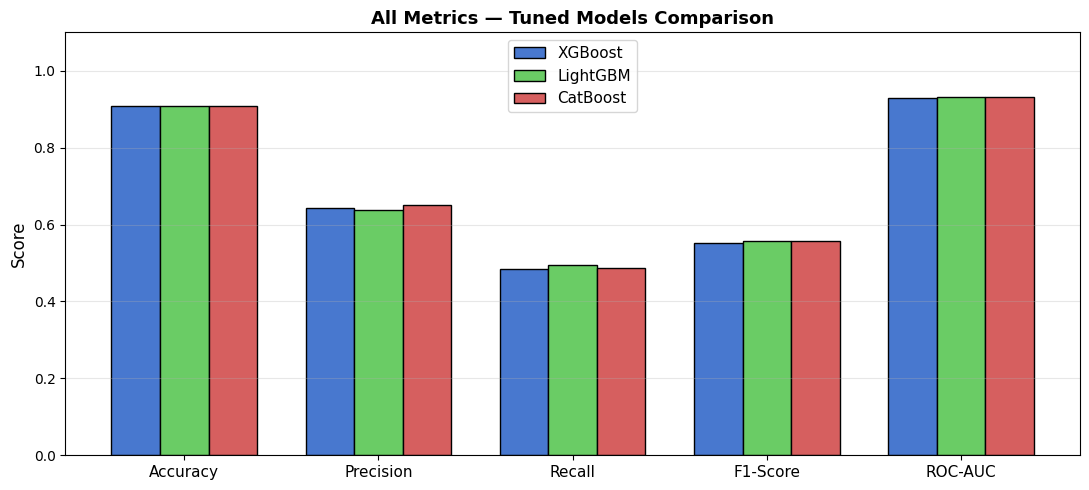

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
xgb_vals = [xgb_tuned_scores[m] for m in metrics]
lgb_vals = [lgb_tuned_scores[m] for m in metrics]
cat_vals = [cat_tuned_scores[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, xgb_vals, width, label='XGBoost',  color='#4878CF', edgecolor='black')
ax.bar(x,         lgb_vals, width, label='LightGBM', color='#6ACC65', edgecolor='black')
ax.bar(x + width, cat_vals, width, label='CatBoost', color='#D65F5F', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("All Metrics — Tuned Models Comparison", fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  Confusion Matrices (Tuned Models)

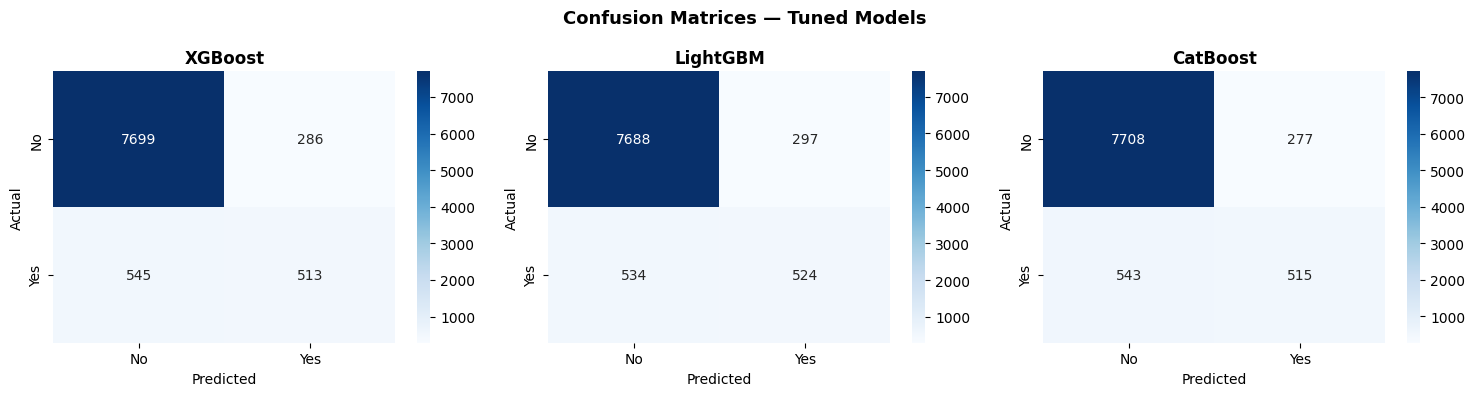

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices — Tuned Models", fontsize=13, fontweight='bold')

tuned_models = {
    'XGBoost' : xgb_search.best_estimator_,
    'LightGBM': lgb_search.best_estimator_,
    'CatBoost': cat_search.best_estimator_,
}

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

###  Feature Importance (Top 10 per Model)

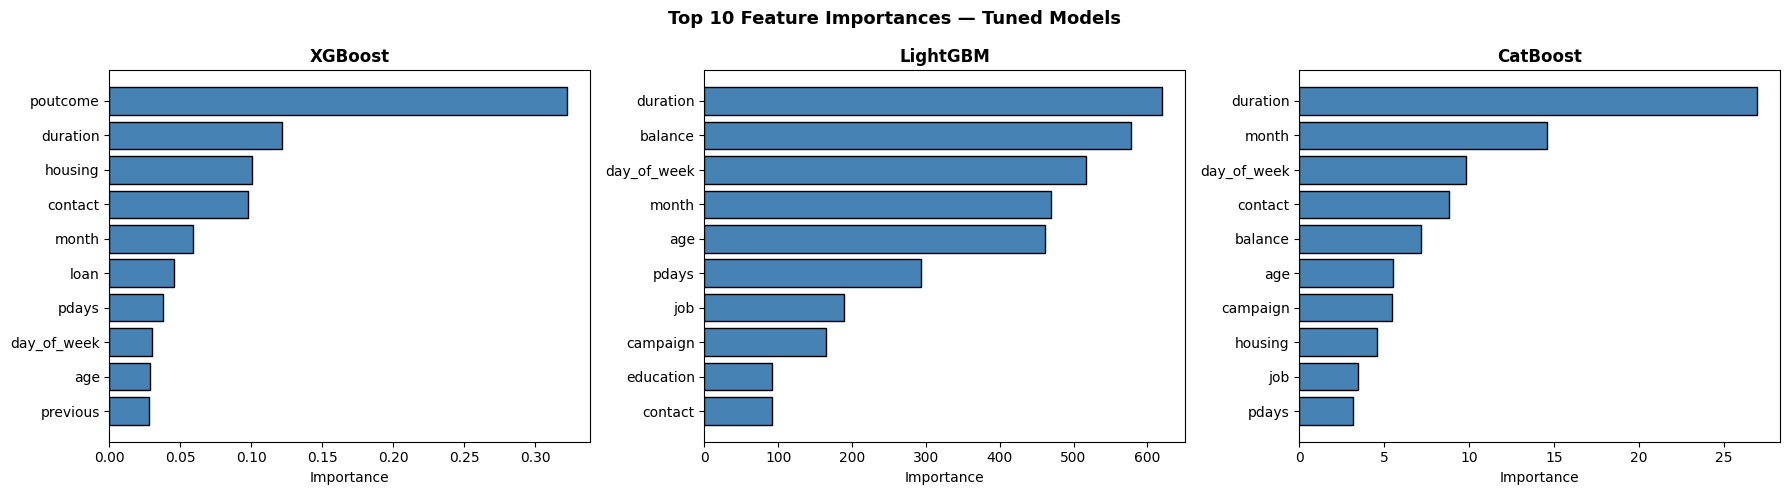

In [ ]:
feature_names = list(X.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Top 10 Feature Importances — Tuned Models", fontsize=13, fontweight='bold')

models_imp = {
    'XGBoost' : xgb_search.best_estimator_,
    'LightGBM': lgb_search.best_estimator_,
    'CatBoost': cat_search.best_estimator_,
}

for ax, (name, model) in zip(axes, models_imp.items()):
    importances = model.feature_importances_

    fi = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': importances
    })
    fi = fi.sort_values('Importance', ascending=False).head(10)
    fi = fi.sort_values('Importance', ascending=True)

    ax.barh(fi['Feature'], fi['Importance'], color='steelblue', edgecolor='black')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

###  ROC-AUC Score Comparison

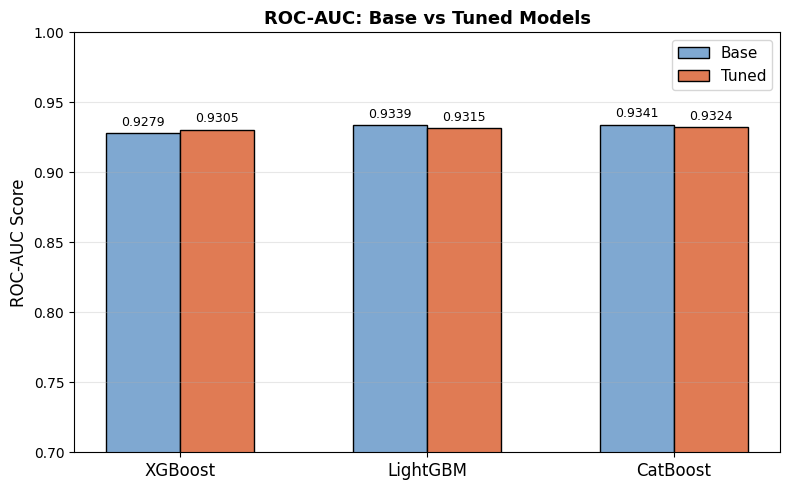

In [ ]:
models_list = ['XGBoost', 'LightGBM', 'CatBoost']
base_auc  = [xgb_base_scores['ROC-AUC'],  lgb_base_scores['ROC-AUC'],  cat_base_scores['ROC-AUC']]
tuned_auc = [xgb_tuned_scores['ROC-AUC'], lgb_tuned_scores['ROC-AUC'], cat_tuned_scores['ROC-AUC']]

x = np.arange(len(models_list))
width = 0.30

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, base_auc,  width, label='Base',  color='#7fa8d1', edgecolor='black')
ax.bar(x + width/2, tuned_auc, width, label='Tuned', color='#e07b54', edgecolor='black')

for i, (b, t) in enumerate(zip(base_auc, tuned_auc)):
    ax.text(i - width/2, b + 0.003, f"{b:.4f}", ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, t + 0.003, f"{t:.4f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=12)
ax.set_ylabel("ROC-AUC Score", fontsize=12)
ax.set_title("ROC-AUC: Base vs Tuned Models", fontsize=13, fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🏆  Final Summary

In [ ]:
print("=" * 55)
print("         FINAL PROJECT SUMMARY")
print("=" * 55)

models_list = ['XGBoost', 'LightGBM', 'CatBoost']
tuned_scores = [xgb_tuned_scores, lgb_tuned_scores, cat_tuned_scores]

best_idx = 0
best_f1  = 0
for i, scores in enumerate(tuned_scores):
    if scores['F1-Score'] > best_f1:
        best_f1  = scores['F1-Score']
        best_idx = i

print(f"\n  Dataset       : Bank Marketing (UCI)")
print(f"  Task          : Binary Classification")
print(f"  Tuning Method : RandomizedSearchCV (n_iter=30, 5-fold CV)")
print(f"  Scoring       : F1-Score")
print()
print(f"  Best Model    : {models_list[best_idx]}")
print(f"  F1-Score      : {tuned_scores[best_idx]['F1-Score']:.4f}")
print(f"  ROC-AUC       : {tuned_scores[best_idx]['ROC-AUC']:.4f}")
print(f"  Accuracy      : {tuned_scores[best_idx]['Accuracy']:.4f}")

print()
print("  Improvement after tuning:")
base_scores_list = [xgb_base_scores, lgb_base_scores, cat_base_scores]
for name, base, tuned in zip(models_list, base_scores_list, tuned_scores):
    delta = tuned['F1-Score'] - base['F1-Score']
    print(f"    {name:<12}  F1 improved by: {delta:+.4f}")

print()
print("=" * 55)

         FINAL PROJECT SUMMARY

  Dataset       : Bank Marketing (UCI)
  Task          : Binary Classification
  Tuning Method : RandomizedSearchCV (n_iter=30, 5-fold CV)
  Scoring       : F1-Score

  Best Model    : LightGBM
  F1-Score      : 0.5577
  ROC-AUC       : 0.9315
  Accuracy      : 0.9081

  Improvement after tuning:
    XGBoost       F1 improved by: +0.0190
    LightGBM      F1 improved by: +0.0076
    CatBoost      F1 improved by: +0.0057

